<a href="https://colab.research.google.com/github/Piyush-Sharma-0/Customer_segmentation_project/blob/main/CBSOT_Customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing pandas, numpy, seabor, matplotlib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
#upload the data before running
df=pd.read_excel("Telco_customer_churn.xlsx")
print("Shape-", df.shape)
print("Information-")
df.info()

Shape- (7043, 33)
Information-
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object

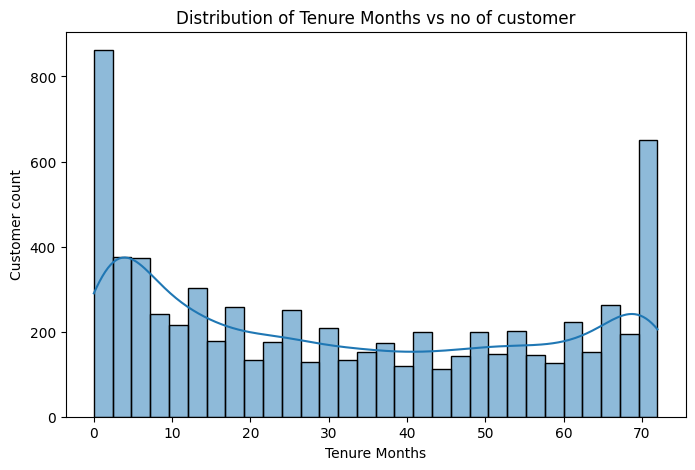

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'], bins=30, kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Months vs no of customer')
plt.show()

Text(0.5, 1.0, 'Churn vs Tenure Months')

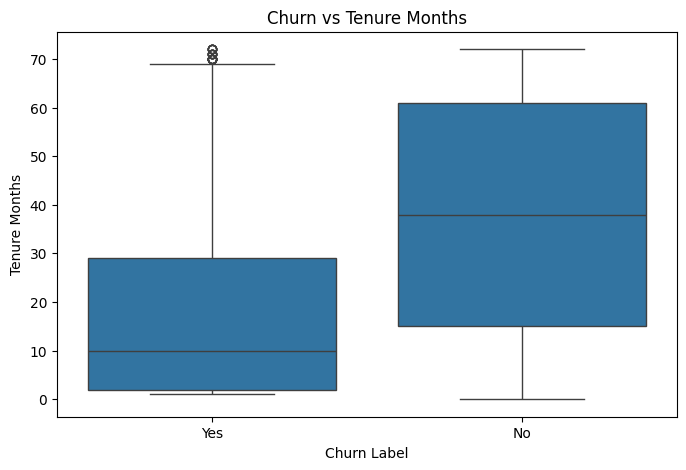

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Tenure Months', data=df)
plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.title('Churn vs Tenure Months')

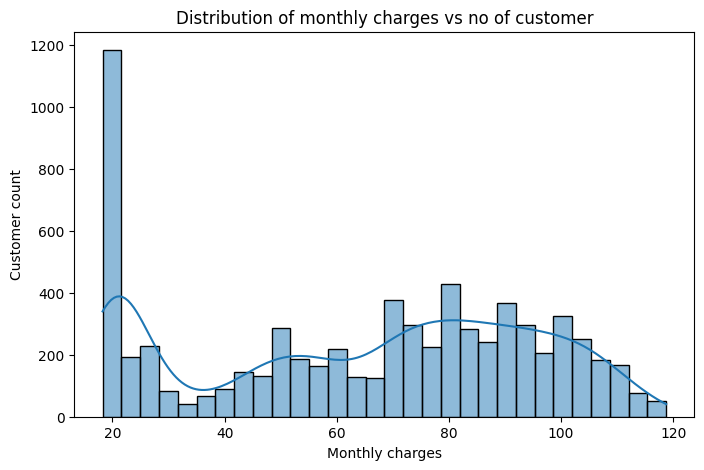

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'], bins=30, kde=True)
plt.xlabel('Monthly charges')
plt.ylabel('Customer count')
plt.title('Distribution of monthly charges vs no of customer')
plt.show()

Text(0.5, 1.0, 'Churn vs Monthly charges')

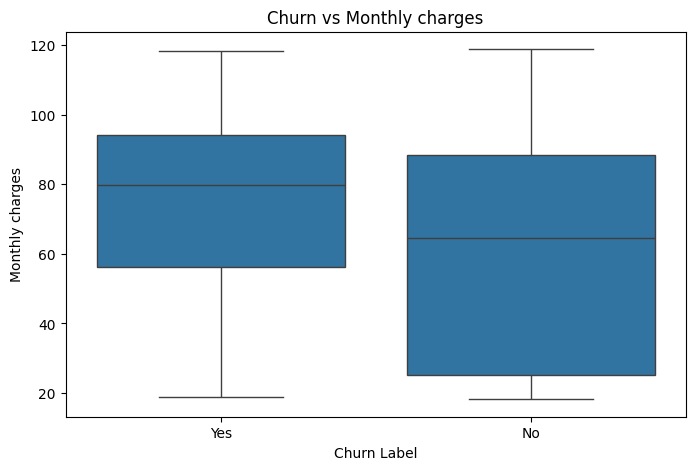

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Monthly Charges', data=df)
plt.xlabel('Churn Label')
plt.ylabel('Monthly charges')
plt.title('Churn vs Monthly charges')

In [ ]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [ ]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [ ]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


Text(0.5, 1.0, 'Contract vs Churn')

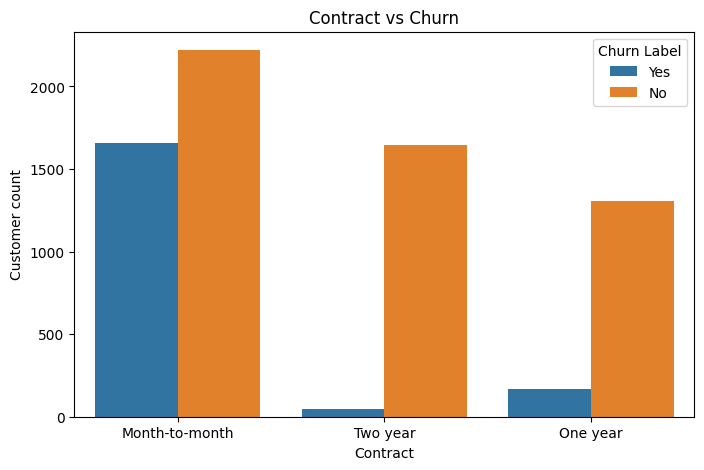

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn Label', data=df)
plt.xlabel('Contract')
plt.ylabel('Customer count')
plt.title('Contract vs Churn')


In [ ]:
df["Internet Service"].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

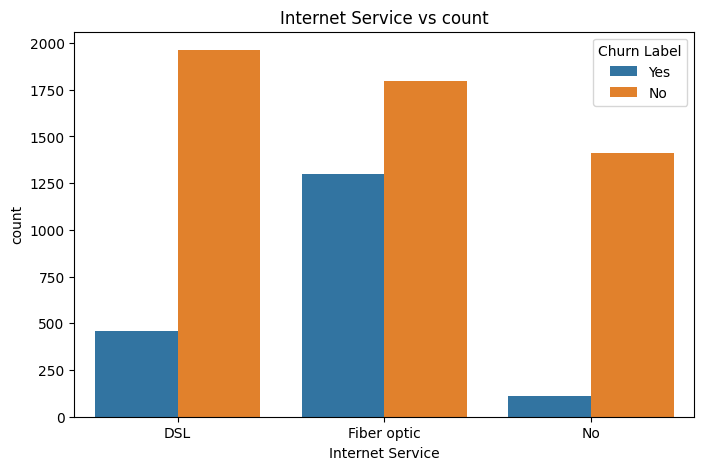

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service', hue='Churn Label', data=df)
plt.xlabel('Internet Service')
plt.ylabel('count')
plt.title('Internet Service vs count')
plt.show()

In [ ]:
df["Payment Method"].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

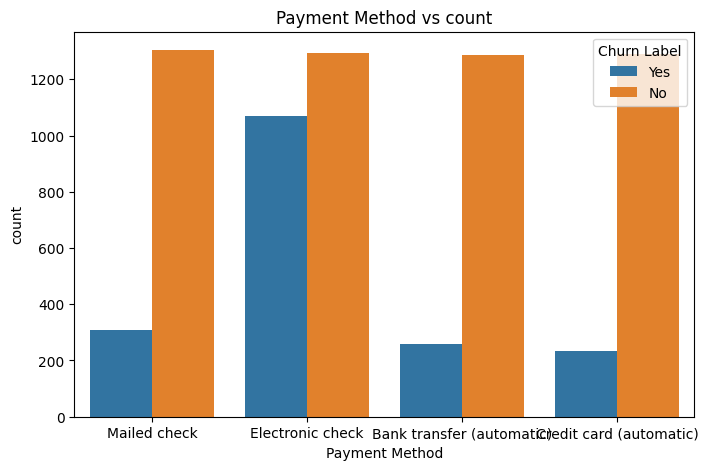

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Payment Method', hue='Churn Label', data=df)
plt.xlabel('Payment Method')
plt.ylabel('count')
plt.title('Payment Method vs count')
plt.show()

In [ ]:
df["Tech Support"].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

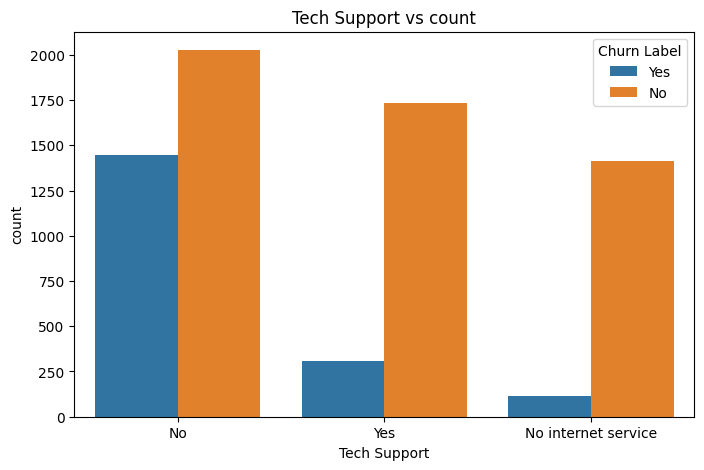

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tech Support', hue='Churn Label', data=df)
plt.xlabel('Tech Support')
plt.ylabel('count')
plt.title('Tech Support vs count')
plt.show()

In [ ]:
avg_tenure=df.groupby('Churn Label')['Tenure Months'].mean()
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


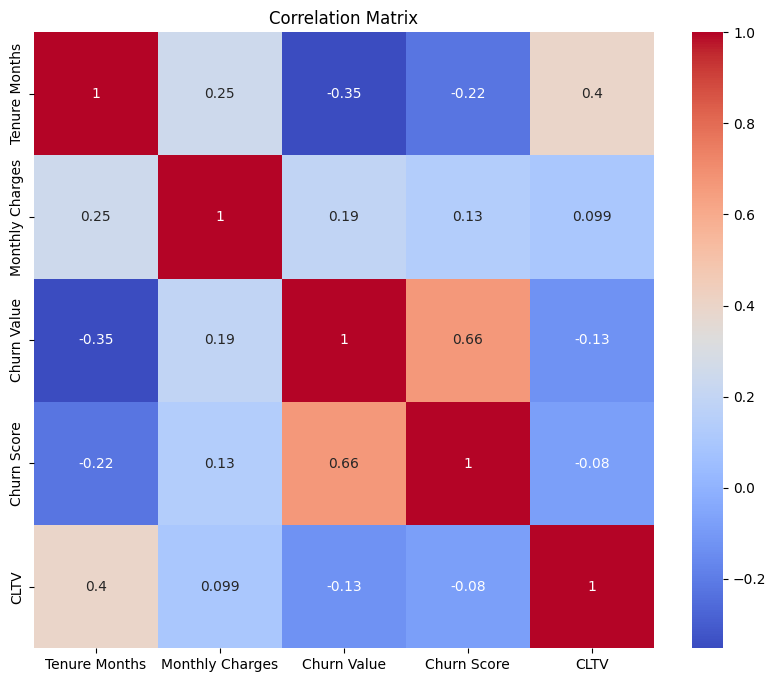

In [ ]:
numerical_cols=["Tenure Months", "Monthly Charges", "Churn Value", "Churn Score", "CLTV"]
correlation_matrix=df[numerical_cols].corr()
correlation_matrix
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()
#'''

In [ ]:
contract_churn=pd.crosstab(df['Contract'], df['Churn Label'],normalize='index')
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


# Data cleaning

In [ ]:
df['Total Charges']=pd.to_numeric(df['Total Charges'], errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [ ]:
df[df['Total Charges'].isnull()]['Tenure Months']

,Tenure Months
2234,0
2438,0
2568,0
2667,0
2856,0
4331,0
4687,0
5104,0
5719,0
6772,0


In [ ]:
df[df['Tenure Months']==0]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,...,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,...,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,...,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,...,Two year,No,Mailed check,25.75,NaN,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,...,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Two year,No,Mailed check,19.85,NaN,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,...,Two year,No,Mailed check,25.35,NaN,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,...,Two year,No,Mailed check,20.00,NaN,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,...,One year,Yes,Mailed check,19.70,NaN,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,...,Two year,No,Mailed check,73.35,NaN,No,0,44,2342,NaN


In [ ]:
df['Total Charges']=df['Total Charges'].fillna(0)

In [ ]:
drop_columns=['CustomerID','Count','Country', 'State','City','Zip Code','Lat Long','Latitude','Longitude','Churn Label','Churn Score','Churn Reason','CLTV']
df=df.drop(drop_columns, axis=1)

In [ ]:
df_encoded=pd.get_dummies(df,drop_first=True)
df_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


In [ ]:
X=df_encoded.drop('Churn Value', axis=1)
Y=df_encoded['Churn Value']
X.shape, Y.shape

((7043, 30), (7043,))

Machine Learning Implementation

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train,y_train)
y_pred=rf_model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)

In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)

In [ ]:
from sklearn.metrics import classification_report
cr=classification_report(y_test,y_pred)

In [ ]:
print(cr)

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1009
           1       0.66      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



**approach 1- Handle class imbalance**

In [ ]:
rf_balanced=RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_balanced.fit(x_train,y_train)
y_pred_balanced=rf_balanced.predict(x_test)
acuracy_balanced=accuracy_score(y_test,y_pred_balanced)
cm_balanced=confusion_matrix(y_test,y_pred_balanced)
cr_balanced=classification_report(y_test,y_pred_balanced)
print(cr_balanced)

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



**approach 2- Hyperparametre tuning**

In [ ]:
rf_tuned=RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')
rf_tuned.fit(x_train,y_train)
y_pred_tuned=rf_tuned.predict(x_test)
accuracy_tuned=accuracy_score(y_test,y_pred_tuned)
cm_tuned=confusion_matrix(y_test,y_pred_tuned)
cr_tuned=classification_report(y_test,y_pred_tuned)
print(cr_tuned)

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



way 3- feature inp analysis

In [ ]:
feaure_importance=pd.DataFrame({'Feature':X.columns, 'Importance':rf_model.feature_importances_})
feaure_importance=feaure_importance.sort_values(by='Importance', ascending=False)
feaure_importance

,Feature,Importance
2,Total Charges,0.190197
0,Tenure Months,0.173457
1,Monthly Charges,0.167753
28,Payment Method_Electronic check,0.038823
6,Dependents_Yes,0.035459
10,Internet Service_Fiber optic,0.034156
25,Contract_Two year,0.029158
3,Gender_Male,0.027464
5,Partner_Yes,0.025513
26,Paperless Billing_Yes,0.025163


In [ ]:
X_selected=X.drop(['Phone Service_Yes','Multiple Lines_No phone service'],axis=1)

In [ ]:
x_train_sel,x_test_sel,y_train_sel,y_test_sel=train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
rf_selected=RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')
rf_selected.fit(x_train_sel,y_train_sel)
y_pred_selected=rf_selected.predict(x_test_sel)
accuracy_selected=accuracy_score(y_test_sel,y_pred_selected)

create a combo of estimator and max depth to get recall more than 75
read KNN, ROC curve

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
n_estimators_list=[100,200,300,400,500]
max_depth_list=[5,10,15,20]
results=[]
for n_trees in n_estimators_list:
    for max_depth in max_depth_list:
        rf_model=RandomForestClassifier(n_estimators=n_trees, max_depth=max_depth, random_state=42, class_weight='balanced')
        rf_model.fit(x_train,y_train)
        y_pred=rf_model.predict(x_test)
        accuracy=accuracy_score(y_test,y_pred)
        recall=recall_score(y_test,y_pred)
        precision=precision_score(y_test,y_pred)
        f1=f1_score(y_test,y_pred)
        results.append({'n_estimators':n_trees, 'max_depth':max_depth, 'accuracy':accuracy, 'recall':recall, 'precision':precision, 'f1':f1})
results_df=pd.DataFrame(results)
results_df

,n_estimators,max_depth,accuracy,recall,precision,f1
0,100,5,0.745919,0.8200,0.534202,0.646943
1,100,10,0.775727,0.7525,0.581081,0.655773
2,100,15,0.802697,0.6300,0.659686,0.644501
3,100,20,0.787793,0.5325,0.655385,0.587586
4,200,5,0.742370,0.8100,0.530278,0.640950
5,200,10,0.782115,0.7450,0.592445,0.660022
6,200,15,0.804826,0.6350,0.663185,0.648787
7,200,20,0.793471,0.5275,0.674121,0.591865
8,300,5,0.743790,0.8200,0.531605,0.645034
9,300,10,0.782825,0.7475,0.593254,0.661504


In [ ]:
from sklearn.model_selection import cross_val_score
final_model=RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')
cv_scores=cross_val_score(final_model,X,Y,cv=5)
cv_accuracy_scores=cross_val_score(final_model,X,Y,cv=5, scoring='accuracy')
cv_recall_scores=cross_val_score(final_model,X,Y,cv=5, scoring='recall')
cv_precision_scores=cross_val_score(final_model,X,Y,cv=5, scoring='precision')


In [ ]:
y_prob1=rf_tuned.predict_proba(x_test)
churn_prob=y_prob1[:,1]
y_prob=rf_tuned.predict_proba(X)
churn_prob=y_prob[:,1]

In [ ]:
from sklearn.metrics import roc_auc_score,roc_curve
fpr,tpr,threshold=roc_curve(Y,y_prob[:,1])
auc_score=roc_auc_score(Y,y_prob[:,1])
print(auc_score)

0.923334828647911


# Customer segmentation

In [ ]:
segmentation_data=pd.DataFrame({
    'Tenure Months':df['Tenure Months'],
    'Monthly Charges':df['Monthly Charges'],
    'Total Charges':df['Total Charges'],
    'Churn probability':y_prob[:,1]
})

segmentation_data.head()

,Tenure Months,Monthly Charges,Total Charges,Churn probability
0,2,53.85,108.15,0.676963
1,2,70.70,151.65,0.796013
2,8,99.65,820.50,0.805827
3,28,104.80,3046.05,0.563031
4,49,103.70,5036.30,0.517474


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
segmentation_data_scaled=scaler.fit_transform(segmentation_data)
std=pd.DataFrame(segmentation_data_scaled)
std

,0,1,2,3
0,-1.236724,-0.362660,-0.958066,1.024868
1,-1.236724,0.197365,-0.938874,1.413854
2,-0.992402,1.159546,-0.643789,1.445918
3,-0.177995,1.330711,0.338085,0.652607
4,0.677133,1.294151,1.216150,0.503752
...,...,...,...,...
7038,1.613701,-1.449476,-0.379565,-1.175321
7039,-0.340876,0.665992,-0.127605,-0.918804
7040,1.613701,1.277533,2.242606,-1.026938
7041,-0.870241,-1.168632,-0.852932,-0.199087


In [ ]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data=scaler.fit_transform(segmentation_data)
print(scaled_data[:5])

[[-1.23672422 -0.36266036 -0.9580659   1.02486837]
 [-1.23672422  0.19736523 -0.93887444  1.4138535 ]
 [-0.99240204  1.1595457  -0.64378925  1.44591771]
 [-0.17799476  1.33071079  0.3380854   0.65260685]
 [ 0.67713287  1.29415125  1.2161497   0.50375182]]


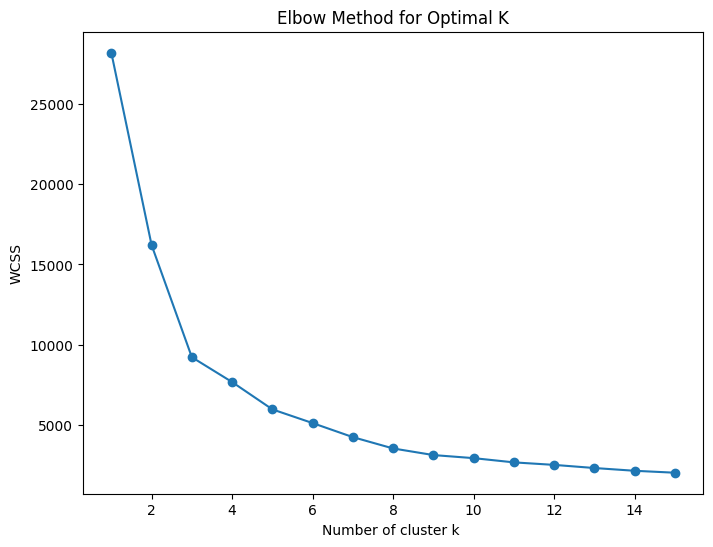

In [ ]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,16):
  kmeans=KMeans(n_clusters=k, random_state=42, n_init='auto')
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(range(1,16),wcss,marker='o')
plt.xlabel("Number of cluster k ")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

In [ ]:
kmeans=KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters=kmeans.fit_predict(scaled_data)
segmentation_data['Cluster']=clusters
cluster_summary=segmentation_data.groupby('Cluster').mean()

In [ ]:
cluster_names={0:'Budget Loyal Customer',1:'High Risk New Customer',2:'Loyal Premium Customer'}
segmentation_data['Cluster Segment']=segmentation_data['Cluster'].map(cluster_names)


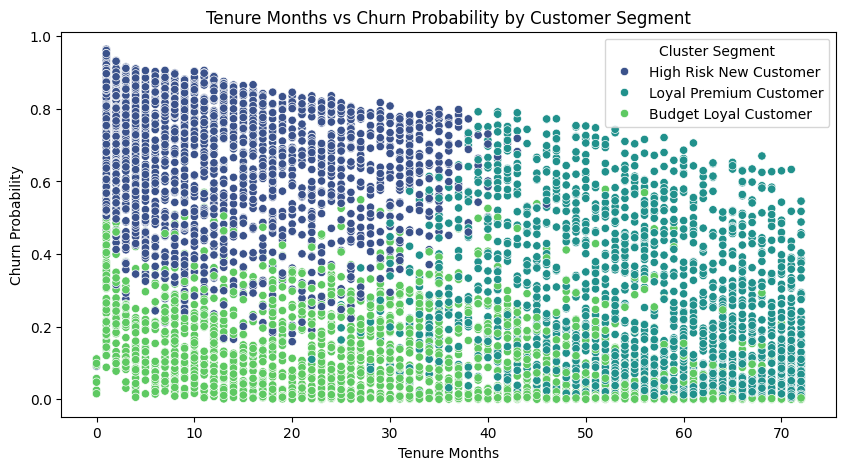

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='Tenure Months', y='Churn probability', hue='Cluster Segment', data=segmentation_data, palette='viridis')
plt.title('Tenure Months vs Churn Probability by Customer Segment')
plt.xlabel('Tenure Months')
plt.ylabel('Churn Probability')
plt.show()

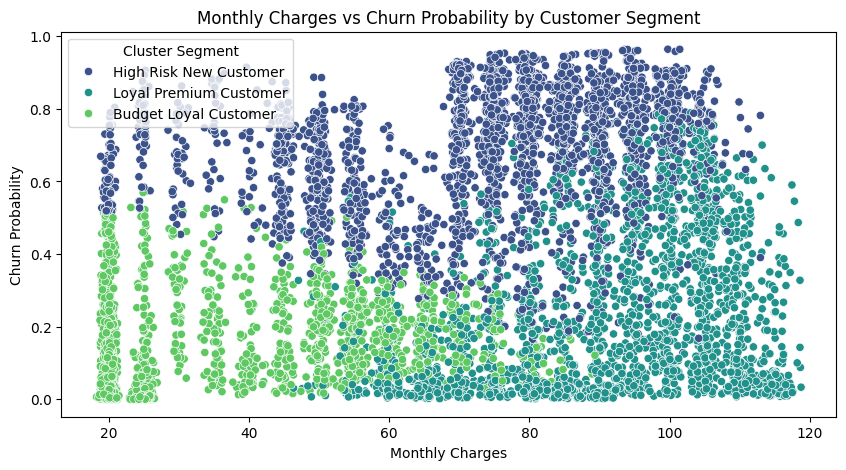

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='Monthly Charges', y='Churn probability', hue='Cluster Segment', data=segmentation_data, palette='viridis')
plt.title('Monthly Charges vs Churn Probability by Customer Segment')
plt.xlabel('Monthly Charges')
plt.ylabel('Churn Probability')
plt.show()

project pipeline--

data cleaning

encoding

eda

feature selecton

train test split

random forest

hyper parametre tuning

feature importance

cross validation

ROC, AUC curve

customer segmentation using kmeans

optimum k value

data visualization

business insights